In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              average_precision_score)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../data/creditcard_clean.csv')

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Scale Amount and Time (V1-V28 are already scaled from PCA)
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])
X['Time'] = scaler.fit_transform(X[['Time']])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Fraud in training: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Fraud in test: {y_test.sum()} ({y_test.mean()*100:.2f}%)")

Training set: 227845 samples
Test set: 56962 samples
Fraud in training: 394 (0.17%)
Fraud in test: 98 (0.17%)


In [3]:
# SMOTE oversamples the minority class (fraud) to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"\nBefore SMOTE:")
print(f"  Legitimate: {(y_train==0).sum()}, Fraud: {(y_train==1).sum()}")
print(f"\nAfter SMOTE:")
print(f"  Legitimate: {(y_train_resampled==0).sum()}, Fraud: {(y_train_resampled==1).sum()}")


Before SMOTE:
  Legitimate: 181056, Fraud: 332

After SMOTE:
  Legitimate: 181056, Fraud: 181056


In [4]:
# Logistic Regression (baseline model)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_resampled, y_train_resampled)

# Predictions
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

# Results
print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(classification_report(y_test, lr_pred, target_names=['Legitimate', 'Fraud']))
print(f"ROC AUC Score: {roc_auc_score(y_test, lr_prob):.4f}")

LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     45265
       Fraud       0.07      0.93      0.12        83

    accuracy                           0.98     45348
   macro avg       0.53      0.95      0.56     45348
weighted avg       1.00      0.98      0.99     45348

ROC AUC Score: 0.9923


In [5]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_resampled, y_train_resampled)

# Predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Results
print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)
print(classification_report(y_test, rf_pred, target_names=['Legitimate', 'Fraud']))
print(f"ROC AUC Score: {roc_auc_score(y_test, rf_prob):.4f}")

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     45265
       Fraud       0.50      0.88      0.64        83

    accuracy                           1.00     45348
   macro avg       0.75      0.94      0.82     45348
weighted avg       1.00      1.00      1.00     45348

ROC AUC Score: 0.9942


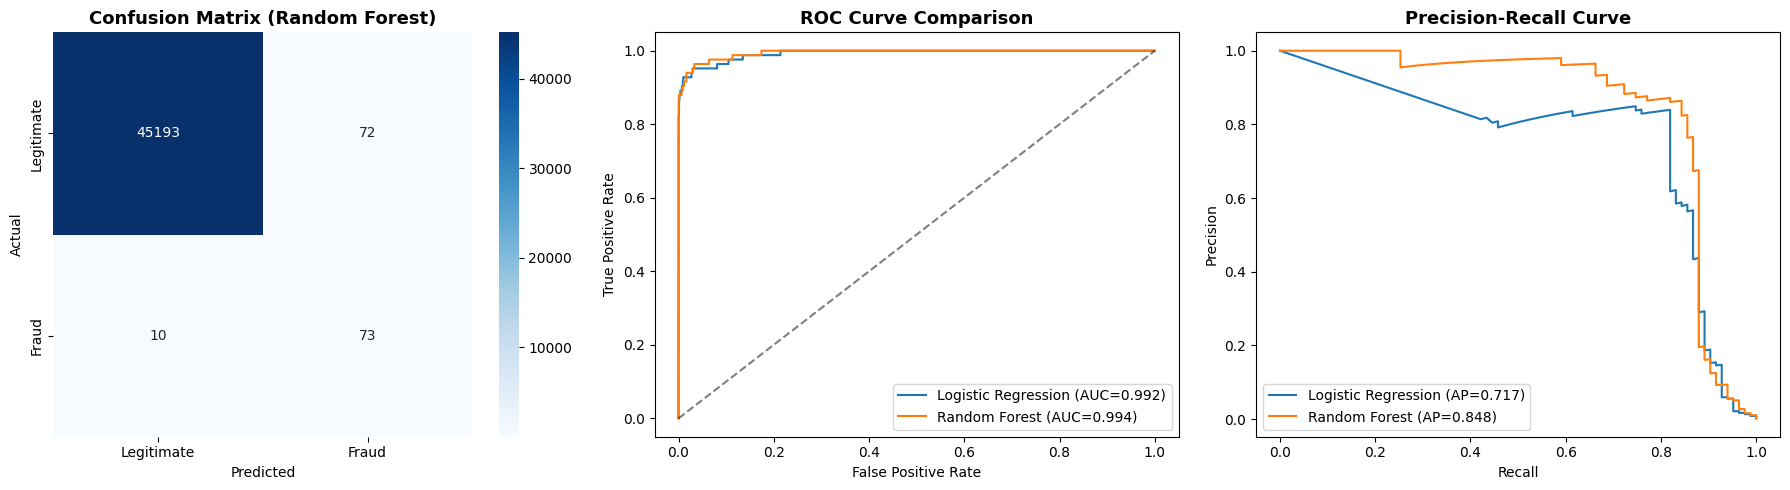

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix — Random Forest (better model)
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
axes[0].set_title('Confusion Matrix (Random Forest)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# 2. ROC Curves — both models
for name, prob in [('Logistic Regression', lr_prob), ('Random Forest', rf_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
axes[1].plot([0,1], [0,1], 'k--', alpha=0.5)
axes[1].set_title('ROC Curve Comparison', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# 3. Precision-Recall Curves
for name, prob in [('Logistic Regression', lr_prob), ('Random Forest', rf_prob)]:
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    axes[2].plot(recall, precision, label=f'{name} (AP={ap:.3f})')
axes[2].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()

plt.tight_layout()
plt.savefig('../images/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

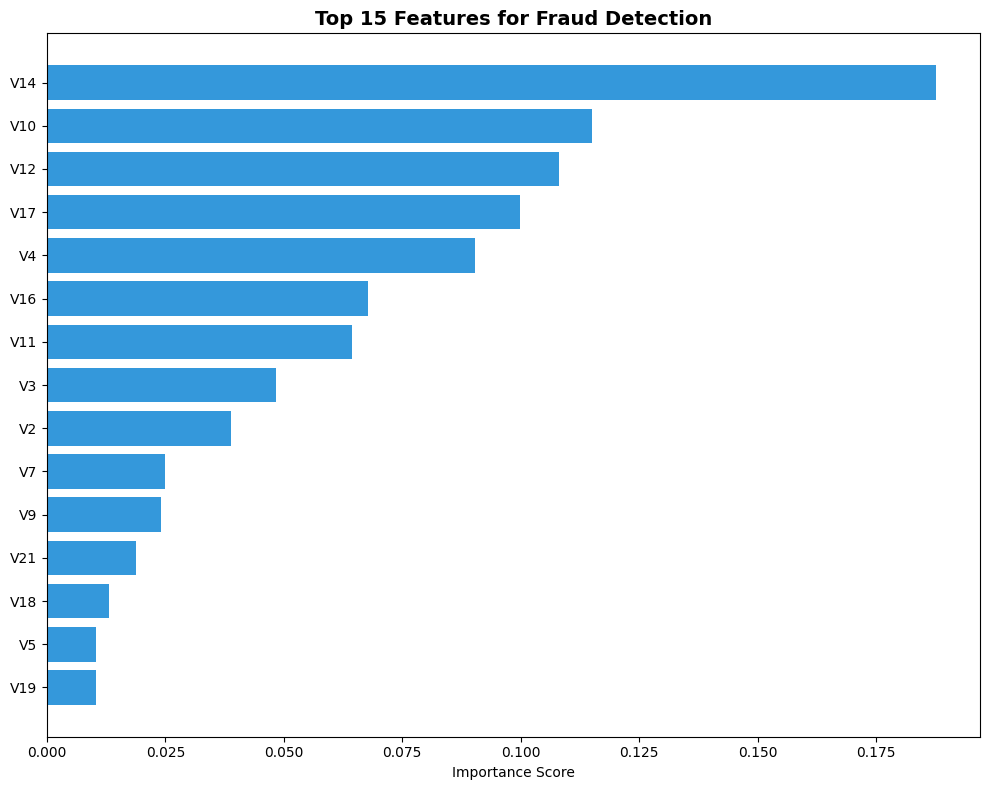

In [7]:
# Top 15 most important features for detecting fraud
importances = rf_model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_imp['Feature'], feat_imp['Importance'], color='#3498db')
ax.set_title('Top 15 Features for Fraud Detection', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../images/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Create a results dataframe for Power BI / Tableau
results_df = X_test.copy()
results_df['Actual'] = y_test.values
results_df['Predicted'] = rf_pred
results_df['Fraud_Probability'] = rf_prob
results_df['Correct'] = (results_df['Actual'] == results_df['Predicted']).astype(int)

# Add Hour back for time analysis in dashboard
results_df['Hour'] = (results_df['Time'] * scaler.scale_[0] + scaler.mean_[0]) / 3600 % 24

results_df.to_csv('../data/model_results.csv', index=False)
print(f"Results saved: {len(results_df)} rows")
print(f"Columns: {list(results_df.columns)}")

Results saved: 45348 rows
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Actual', 'Predicted', 'Fraud_Probability', 'Correct', 'Hour']


In [ ]:
# --- Class Imbalance Handling + Model Training ---

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Prepare features
X = df.drop('Class', axis=1)
y = df['Class']

scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])
X['Time'] = scaler.fit_transform(X[['Time']])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE — balance the 0.17% fraud class
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_resampled, y_resampled)

# Evaluate
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_pred, target_names=['Legitimate', 'Fraud']))
print(f"ROC AUC: {roc_auc_score(y_test, rf_prob):.4f}")